# CNN Baseline (v1)

Standard CNN on raw sEMG windows (8×50) as 2D images. Full data, MPS accelerated.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import MODELS_DIR, RANDOM_SEED, N_CLASSES, get_device
from src.data_splitter import (
    scenario_1_ideal,
    scenario_2_per_position,
    scenario_3_inter_subject,
    scenario_4_interday,
    scenario_5_fatigue,
)
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## Model definition

In [2]:
class StandardCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = StandardCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(model)

Parameters: 101,831
StandardCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU(

## Training utilities

In [3]:
def to_tensor(X, y):
    # (N, 8, 50) -> (N, 1, 8, 50) for Conv2d
    X_t = torch.from_numpy(X).float().unsqueeze(1)
    y_t = torch.from_numpy(y).long()
    return X_t, y_t


def make_loader(X, y, batch_size=256, shuffle=True):
    X_t, y_t = to_tensor(X, y)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, n_epochs=30, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        scheduler.step()
        epoch_loss = total_loss / total
        epoch_acc = correct / total
        history.append({"loss": epoch_loss, "acc": epoch_acc})
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} — loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f}")
    return history


@torch.no_grad()
def predict(model, X):
    model.eval()
    X_t = torch.from_numpy(X).float().unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds = []
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        preds.append(model(xb).argmax(1).cpu().numpy())
    return np.concatenate(preds)


def train_and_eval(X_train, y_train, X_test, y_test, title, n_epochs=30, lr=1e-3):
    model = StandardCNN().to(DEVICE)
    loader = make_loader(X_train, y_train)
    history = train_model(model, loader, n_epochs=n_epochs, lr=lr)
    y_pred = predict(model, X_test)
    metrics = print_report(y_test, y_pred, title=title)
    plot_confusion_matrix(y_test, y_pred, title=title)
    return model, history, metrics

---
## Scenario 1 — Ideal

In [4]:
X_train, y_train, X_test, y_test, info = scenario_1_ideal()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 1367.67it/s]


Train: (59159, 8, 50), Test: (29281, 8, 50)


Epoch   1/30 — loss: 1.1966, acc: 0.5558
Epoch   5/30 — loss: 0.7105, acc: 0.7414
Epoch  10/30 — loss: 0.5601, acc: 0.7975
Epoch  15/30 — loss: 0.4438, acc: 0.8388
Epoch  20/30 — loss: 0.3938, acc: 0.8573
Epoch  25/30 — loss: 0.3432, acc: 0.8752
Epoch  30/30 — loss: 0.3218, acc: 0.8832

  CNN — Scenario 1 (Ideal)
  Accuracy:  0.7578
  F1-macro:  0.7571
                    precision    recall  f1-score   support

              fist       0.91      0.84      0.87      4208
         open_hand       0.76      0.68      0.71      4179
  pinch_forefinger       0.71      0.55      0.62      4204
pinch_middlefinger       0.62      0.82      0.70      4239
               two       0.78      0.70      0.74      4175
          eversion       0.90      0.79      0.84      4064
             varus       0.72      0.92      0.81      4212

          accuracy                           0.76     29281
         macro avg       0.77      0.76      0.76     29281
      weighted avg       0.77      0.76    

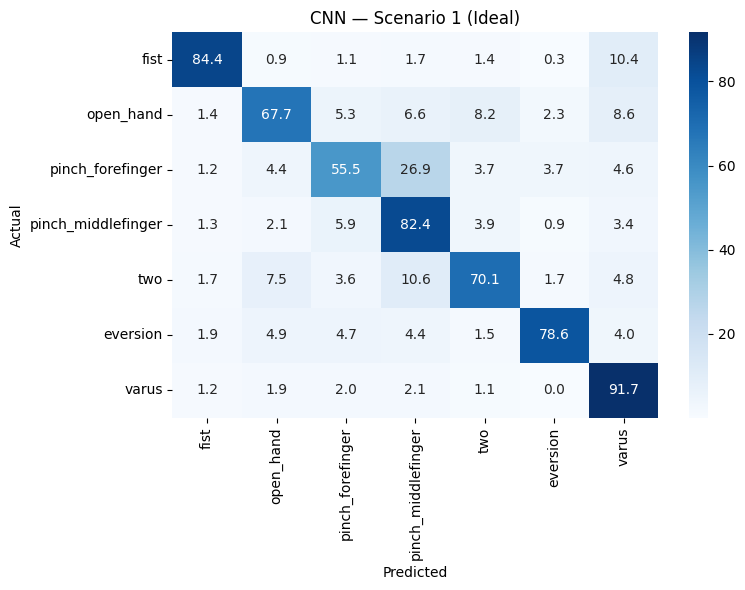

In [5]:
cnn_s1, hist_s1, metrics_s1 = train_and_eval(X_train, y_train, X_test, y_test, "CNN — Scenario 1 (Ideal)")

In [22]:
# Per-subject CNN evaluation (sanity check)
from src.data_splitter import load_metadata, load_windows_from_metadata, compute_normalization_stats, apply_normalization

meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["position"] == 0)]

per_subject_acc = {}
for subj in sorted(subset["subject"].unique()):
    subj_df = subset[subset["subject"] == subj]
    train_df = subj_df[subj_df["repetition"].isin([0, 1])]
    test_df = subj_df[subj_df["repetition"] == 2]

    X_tr, y_tr = load_windows_from_metadata(train_df, verbose=False)
    X_te, y_te = load_windows_from_metadata(test_df, verbose=False)

    mean, std = compute_normalization_stats(X_tr)
    X_tr = apply_normalization(X_tr, mean, std)
    X_te = apply_normalization(X_te, mean, std)

    m = StandardCNN().to(DEVICE)
    loader = make_loader(X_tr, y_tr, batch_size=128)
    train_model(m, loader, n_epochs=30, lr=1e-3)
    y_pred = predict(m, X_te)
    per_subject_acc[subj] = accuracy_score(y_te, y_pred)

accs = list(per_subject_acc.values())
print(f"Per-subject accuracy: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
print()
for subj, acc in sorted(per_subject_acc.items()):
    bar = "█" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Epoch   1/30 — loss: 1.7001, acc: 0.4170
Epoch   5/30 — loss: 0.4259, acc: 0.8930
Epoch  10/30 — loss: 0.2305, acc: 0.9199
Epoch  15/30 — loss: 0.1997, acc: 0.9250
Epoch  20/30 — loss: 0.1996, acc: 0.9270
Epoch  25/30 — loss: 0.1905, acc: 0.9231
Epoch  30/30 — loss: 0.1786, acc: 0.9379
Epoch   1/30 — loss: 1.8445, acc: 0.2717
Epoch   5/30 — loss: 0.9060, acc: 0.7665
Epoch  10/30 — loss: 0.3144, acc: 0.9187
Epoch  15/30 — loss: 0.2187, acc: 0.9299
Epoch  20/30 — loss: 0.1553, acc: 0.9538
Epoch  25/30 — loss: 0.1411, acc: 0.9562
Epoch  30/30 — loss: 0.1349, acc: 0.9641
Epoch   1/30 — loss: 1.6698, acc: 0.4308
Epoch   5/30 — loss: 0.3940, acc: 0.9043
Epoch  10/30 — loss: 0.1540, acc: 0.9548
Epoch  15/30 — loss: 0.1092, acc: 0.9698
Epoch  20/30 — loss: 0.0935, acc: 0.9692
Epoch  25/30 — loss: 0.0708, acc: 0.9797
Epoch  30/30 — loss: 0.0587, acc: 0.9875
Epoch   1/30 — loss: 1.6983, acc: 0.4382
Epoch   5/30 — loss: 0.4335, acc: 0.8813
Epoch  10/30 — loss: 0.1409, acc: 0.9635
Epoch  15/30 — l

In [6]:
torch.save(cnn_s1.state_dict(), MODELS_DIR / "cnn_s1_ideal.pt")
print("Saved.")

Saved.


---
## Scenario 2 — Electrode Shift (per-position curve)

In [7]:
X_train_s2, y_train_s2, test_by_pos, info_s2 = scenario_2_per_position()
print(f"Train: {X_train_s2.shape}")

Loading windows: 100%|██████████| 629/629 [00:00<00:00, 1518.74it/s]


Train: (71927, 8, 50)


In [8]:
cnn_s2 = StandardCNN().to(DEVICE)
loader_s2 = make_loader(X_train_s2, y_train_s2)
hist_s2 = train_model(cnn_s2, loader_s2, n_epochs=30)

Epoch   1/30 — loss: 1.1486, acc: 0.5777
Epoch   5/30 — loss: 0.6638, acc: 0.7595
Epoch  10/30 — loss: 0.5135, acc: 0.8138
Epoch  15/30 — loss: 0.4100, acc: 0.8514
Epoch  20/30 — loss: 0.3684, acc: 0.8664
Epoch  25/30 — loss: 0.3149, acc: 0.8862
Epoch  30/30 — loss: 0.2880, acc: 0.8952


Position  1: acc = 0.3620
Position  2: acc = 0.2597
Position  3: acc = 0.2365
Position  4: acc = 0.2016
Position  5: acc = 0.1982
Position  6: acc = 0.2308
Position  7: acc = 0.3552
Position  8: acc = 0.4312
Position  9: acc = 0.1794
Position 10: acc = 0.1866


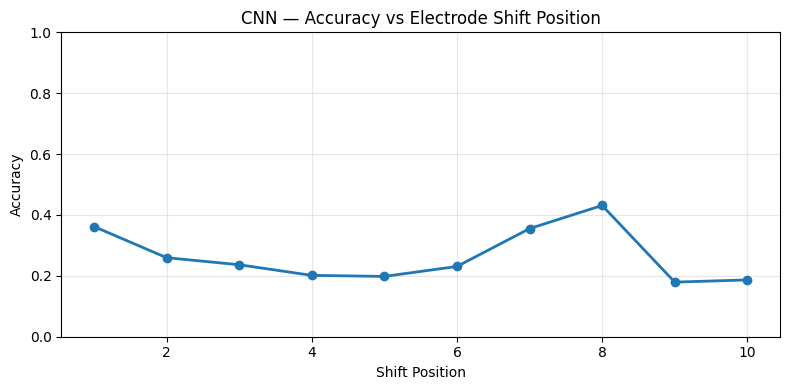

In [9]:
acc_per_pos = {}
for pos, (X_pos, y_pos) in sorted(test_by_pos.items()):
    y_pred = predict(cnn_s2, X_pos)
    acc_per_pos[pos] = accuracy_score(y_pos, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_pos[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_pos.keys()), list(acc_per_pos.values()), "o-", linewidth=2)
plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("CNN — Accuracy vs Electrode Shift Position")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "cnn_shift_curve.png"), dpi=150)
plt.show()

In [23]:
# S2b — Calibration setup (train p0,p3,p6, test remaining)
from src.data_splitter import load_metadata, load_windows_from_metadata, compute_normalization_stats, apply_normalization
from config import SUBJECTS_NON_FATIGUE

meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["subject"].isin(SUBJECTS_NON_FATIGUE))]

TRAIN_POS = [0, 3, 6]
TEST_POS = [p for p in range(11) if p not in TRAIN_POS]

train_df = subset[subset["position"].isin(TRAIN_POS)]
test_df = subset[subset["position"].isin(TEST_POS)]

X_tr, y_tr = load_windows_from_metadata(train_df)
mean, std = compute_normalization_stats(X_tr)
X_tr = apply_normalization(X_tr, mean, std)

X_test_all = {}
for pos in TEST_POS:
    pos_df = subset[subset["position"] == pos]
    X_p, y_p = load_windows_from_metadata(pos_df, verbose=False)
    X_p = apply_normalization(X_p, mean, std)
    X_test_all[pos] = (X_p, y_p)

cnn_s2b = StandardCNN().to(DEVICE)
loader_s2b = make_loader(X_tr, y_tr)
train_model(cnn_s2b, loader_s2b, n_epochs=30)

acc_s2b = {}
for pos in TEST_POS:
    X_p, y_p = X_test_all[pos]
    y_pred = predict(cnn_s2b, X_p)
    acc_s2b[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: acc = {acc_s2b[pos]:.4f}")

print(f"\nCNN S2 calibration avg: {np.mean(list(acc_s2b.values())):.4f}")

Loading windows: 100%|██████████| 1887/1887 [00:00<00:00, 2396.99it/s]


Epoch   1/30 — loss: 1.2994, acc: 0.5092
Epoch   5/30 — loss: 0.8446, acc: 0.6935
Epoch  10/30 — loss: 0.6821, acc: 0.7548
Epoch  15/30 — loss: 0.5727, acc: 0.7958
Epoch  20/30 — loss: 0.5301, acc: 0.8110
Epoch  25/30 — loss: 0.4814, acc: 0.8285
Epoch  30/30 — loss: 0.4617, acc: 0.8365
Position  1: acc = 0.3763
Position  2: acc = 0.4548
Position  4: acc = 0.3990
Position  5: acc = 0.4631
Position  7: acc = 0.4686
Position  8: acc = 0.4807
Position  9: acc = 0.4501
Position 10: acc = 0.4416

CNN S2 calibration avg: 0.4418


In [10]:
torch.save(cnn_s2.state_dict(), MODELS_DIR / "cnn_s2_shift.pt")
print("Saved.")

Saved.


---
## Scenario 3 — Inter-Subject

In [11]:
X_train_s3, y_train_s3, X_test_s3, y_test_s3, info_s3 = scenario_3_inter_subject()
print(f"Train: {X_train_s3.shape} ({len(info_s3['train_subjects'])} subjects)")
print(f"Test:  {X_test_s3.shape} ({info_s3['test_subjects']})")

Loading windows: 100%|██████████| 1385/1385 [00:00<00:00, 1600.44it/s]


Train: (618926, 8, 50) (24 subjects)
Test:  (168232, 8, 50) (['h7', 'h22', 'h3', 'h24', 'h16', 'h17'])


Epoch   1/30 — loss: 1.2984, acc: 0.5066
Epoch   5/30 — loss: 0.9218, acc: 0.6646
Epoch  10/30 — loss: 0.8088, acc: 0.7073
Epoch  15/30 — loss: 0.7302, acc: 0.7372
Epoch  20/30 — loss: 0.7087, acc: 0.7455
Epoch  25/30 — loss: 0.6703, acc: 0.7598
Epoch  30/30 — loss: 0.6617, acc: 0.7628

  CNN — Scenario 3 (Inter-Subject)
  Accuracy:  0.5290
  F1-macro:  0.5213
                    precision    recall  f1-score   support

              fist       0.67      0.52      0.59     23888
         open_hand       0.46      0.58      0.51     23933
  pinch_forefinger       0.41      0.30      0.34     24284
pinch_middlefinger       0.53      0.37      0.43     24064
               two       0.58      0.53      0.55     23897
          eversion       0.58      0.78      0.66     24069
             varus       0.50      0.63      0.56     24097

          accuracy                           0.53    168232
         macro avg       0.53      0.53      0.52    168232
      weighted avg       0.53      

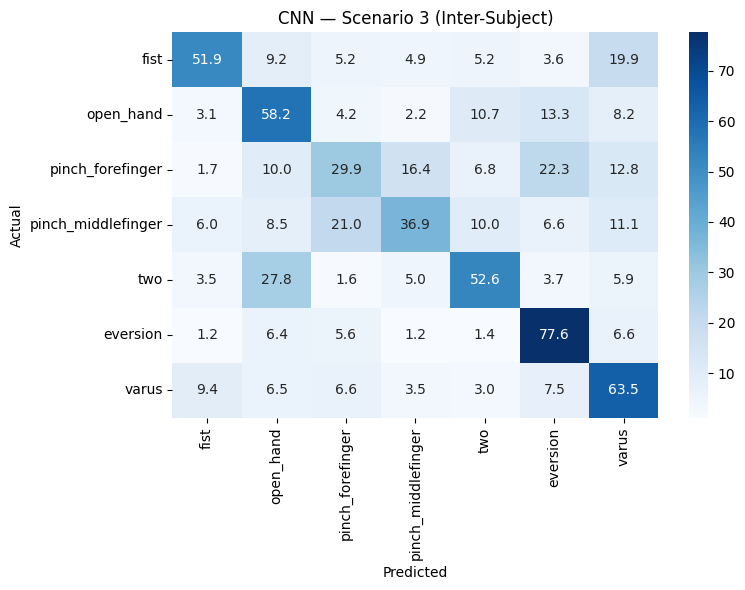

In [12]:
cnn_s3, hist_s3, metrics_s3 = train_and_eval(
    X_train_s3, y_train_s3, X_test_s3, y_test_s3,
    "CNN — Scenario 3 (Inter-Subject)", n_epochs=30
)

In [13]:
torch.save(cnn_s3.state_dict(), MODELS_DIR / "cnn_s3_intersubject.pt")
print("Saved.")

Saved.


---
## Scenario 4 — Inter-Day

In [14]:
X_train_s4, y_train_s4, test_by_sess, info_s4 = scenario_4_interday()
print(f"Train: {X_train_s4.shape}")

Loading windows: 100%|██████████| 126/126 [00:00<00:00, 1539.20it/s]


Train: (13445, 8, 50)


In [15]:
cnn_s4 = StandardCNN().to(DEVICE)
loader_s4 = make_loader(X_train_s4, y_train_s4)
hist_s4 = train_model(cnn_s4, loader_s4, n_epochs=30)

Epoch   1/30 — loss: 1.4181, acc: 0.4715
Epoch   5/30 — loss: 0.4995, acc: 0.8158
Epoch  10/30 — loss: 0.3305, acc: 0.8763
Epoch  15/30 — loss: 0.2517, acc: 0.9070
Epoch  20/30 — loss: 0.2098, acc: 0.9220
Epoch  25/30 — loss: 0.1827, acc: 0.9322
Epoch  30/30 — loss: 0.1755, acc: 0.9345


Session 1: acc = 0.6292
Session 2: acc = 0.7160
Session 3: acc = 0.6944
Session 4: acc = 0.6985
Session 5: acc = 0.6378
Session 6: acc = 0.7162
Session 7: acc = 0.6583
Session 8: acc = 0.7036
Session 9: acc = 0.6031


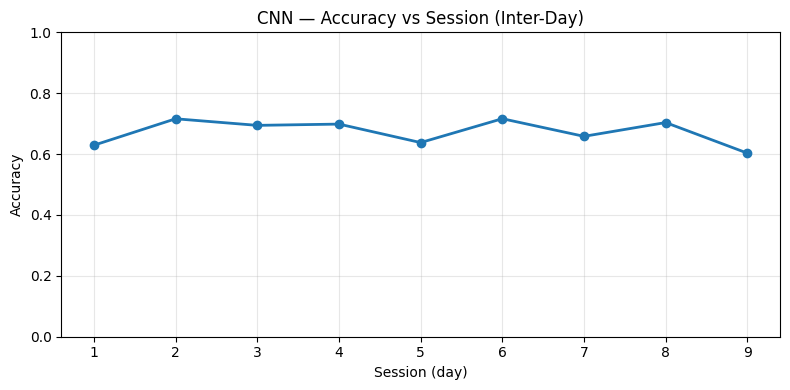

In [16]:
acc_per_sess = {}
for sess, (X_s, y_s) in sorted(test_by_sess.items()):
    y_pred = predict(cnn_s4, X_s)
    acc_per_sess[sess] = accuracy_score(y_s, y_pred)
    print(f"Session {sess}: acc = {acc_per_sess[sess]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_sess.keys()), list(acc_per_sess.values()), "o-", linewidth=2)
plt.xlabel("Session (day)")
plt.ylabel("Accuracy")
plt.title("CNN — Accuracy vs Session (Inter-Day)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "cnn_interday_curve.png"), dpi=150)
plt.show()

---
## Scenario 5 — Fatigue

In [17]:
X_train_s5, y_train_s5, test_by_fatigue, info_s5 = scenario_5_fatigue()
print(f"Train: {X_train_s5.shape}")

Loading windows: 100%|██████████| 252/252 [00:00<00:00, 1543.34it/s]


Train: (33046, 8, 50)


In [18]:
cnn_s5 = StandardCNN().to(DEVICE)
loader_s5 = make_loader(X_train_s5, y_train_s5)
hist_s5 = train_model(cnn_s5, loader_s5, n_epochs=30)

Epoch   1/30 — loss: 0.9863, acc: 0.6462
Epoch   5/30 — loss: 0.3316, acc: 0.8790
Epoch  10/30 — loss: 0.2594, acc: 0.9040
Epoch  15/30 — loss: 0.2089, acc: 0.9226
Epoch  20/30 — loss: 0.1913, acc: 0.9285
Epoch  25/30 — loss: 0.1689, acc: 0.9361
Epoch  30/30 — loss: 0.1654, acc: 0.9373


Position  2: acc = 0.8779
Position  3: acc = 0.8650
Position  4: acc = 0.8730
Position  5: acc = 0.8869
Position  6: acc = 0.8775
Position  7: acc = 0.8880
Position  8: acc = 0.8476
Position  9: acc = 0.8666
Position 10: acc = 0.8460


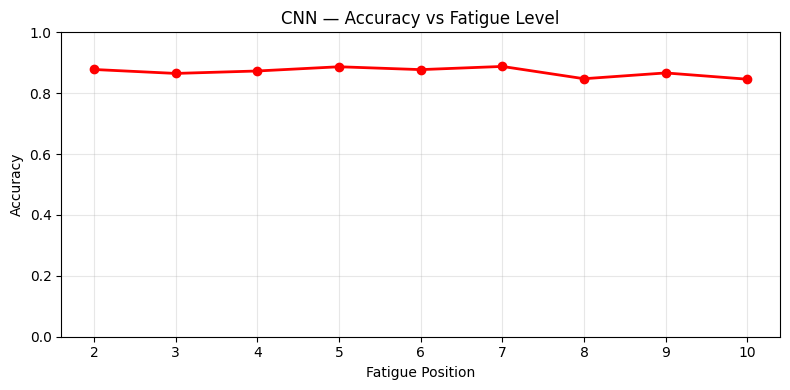

In [19]:
acc_per_fatigue = {}
for pos, (X_p, y_p) in sorted(test_by_fatigue.items()):
    y_pred = predict(cnn_s5, X_p)
    acc_per_fatigue[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_fatigue[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_fatigue.keys()), list(acc_per_fatigue.values()), "o-", linewidth=2, color="red")
plt.xlabel("Fatigue Position")
plt.ylabel("Accuracy")
plt.title("CNN — Accuracy vs Fatigue Level")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "cnn_fatigue_curve.png"), dpi=150)
plt.show()

---
## Latency Measurement

In [20]:
cnn_s1.eval()
sample = torch.from_numpy(X_train[:1]).float().unsqueeze(1).to(DEVICE)

# Warm-up
for _ in range(10):
    _ = cnn_s1(sample)
if DEVICE.type == "mps":
    torch.mps.synchronize()

def cnn_predict_single(x):
    with torch.no_grad():
        out = cnn_s1(x)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

latency = measure_latency(cnn_predict_single, sample, n_runs=500)
print_latency(latency, model_name="CNN Standard")
print(f"Parameters: {sum(p.numel() for p in cnn_s1.parameters()):,}")


Latency — CNN Standard
  Mean:   1.32 ms
  Median: 1.25 ms
  P95:    1.74 ms
  <300ms: ✓
Parameters: 101,831


---
## Summary

In [21]:
print("\n" + "=" * 50)
print("CNN BASELINE — ALL SCENARIOS")
print("=" * 50)
print(f"S1 Ideal:         acc = {metrics_s1['accuracy']:.4f}, f1 = {metrics_s1['f1_macro']:.4f}")
print(f"S2 Shift (avg):   acc = {np.mean(list(acc_per_pos.values())):.4f}")
print(f"S3 Inter-subject: acc = {metrics_s3['accuracy']:.4f}, f1 = {metrics_s3['f1_macro']:.4f}")
print(f"S4 Inter-day (avg): acc = {np.mean(list(acc_per_sess.values())):.4f}")
print(f"S5 Fatigue (avg): acc = {np.mean(list(acc_per_fatigue.values())):.4f}")
print(f"Latency (p95):    {latency['p95_ms']:.2f} ms")
print(f"Parameters:       {sum(p.numel() for p in cnn_s1.parameters()):,}")
print("=" * 50)


CNN BASELINE — ALL SCENARIOS
S1 Ideal:         acc = 0.7578, f1 = 0.7571
S2 Shift (avg):   acc = 0.2641
S3 Inter-subject: acc = 0.5290, f1 = 0.5213
S4 Inter-day (avg): acc = 0.6730
S5 Fatigue (avg): acc = 0.8698
Latency (p95):    1.74 ms
Parameters:       101,831
